This notebook demonstrates how to load **panellinies_exams_dataset** from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from datasets import load_dataset
from dotenv import load_dotenv, find_dotenv

sys.path.append(os.path.abspath('..'))

from src.eda_utils import (
    # --- Data Presentation ---
    display_samples,
    print_sample, 
    display_qa,
    
    # --- Multimodal (Images) ---
    get_image_samples_df,
    display_multimodal_samples, 
    
    # --- Distributions & Plots ---
    plot_subject_dist,      
    plot_school_type_dist,       
    plot_format_dist,       
    plot_reference_dist,    
    plot_temporal_distribution,
    plot_format_by_subject,      
    
    # --- Points Analysis ---
    plot_points_distribution,
    plot_points_by_school_type, 
    plot_points_by_subject,     
    
    # --- Source Tracking ---
    print_source_files
)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")

Using Repository: PennyK98/panellinies_exams_dataset


**1. Load the dataset**

In [8]:
dataset = load_dataset(repo_id, split="train", token=token, download_mode="force_redownload")
df = dataset.to_pandas()

print(f"✅ Dataset loaded. Total rows: {len(df)}")

c:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\panag\.cache\huggingface\hub\datasets--PennyK98--panellinies_exams_dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|

✅ Dataset loaded. Total rows: 1318


**2. Main samples inspection**

In [31]:
# Μαθηματικά, Φυσική, Χημεία, Βιολογία, Πληροφορική
science_df = df[df['subject'].isin(['mathematics', 'physics', 'chemistry', 'biology', 'computer_science'])]
all_science_ids = science_df['id'].tolist()
random_id_sc = random.choice(all_science_ids)

# Νεοελληνική Γλώσσα, Αρχαία, Ιστορία, Λατινικά, ΑΟΘ
humanities_df = df[df['subject'].isin(['greek_language', 'ancient_greek', 'history', 'latin', 'economics'])]
all_humanities_ids = humanities_df['id'].tolist()
random_id_hum = random.choice(all_humanities_ids)

# --- Στοχευμένα IDs ---
target_id = 'physics_gel_2025_Δ3'
#chemistry_gel_2020_Δ3.i 
#physics_gel_2025_Δ3
test_id = 'ancient_greek_gel_2025_Α1.α.1'

# --- Τυχαίο δείγμα Θετικών ---
display_qa(df, random_id_sc)
#display_qa(df, target_id)

print_source_files(df, sample_id=random_id_sc)
#print_source_files(df, sample_id=target_id)

# --- Συγκεκριμένο δείγμα ---
display_qa(df, test_id)
print_source_files(df, sample_id=test_id)

🔍 Identifying source files for ID: mathematics_gel_2021_Δ2
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2021\GEL\mathimatika\them_math_gel_2021.json](..\data\2021\GEL\mathimatika\them_math_gel_2021.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2021\GEL\mathimatika\apant_math_gel_2021.md](..\data\2021\GEL\mathimatika\apant_math_gel_2021.md)

--------------------------------------------------


🔍 Identifying source files for ID: ancient_greek_gel_2025_Α1.α.1
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json](..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md](..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md)

--------------------------------------------------


**3. Multimodal Analysis**

id,subject,format,reference,question,input,image,choices,answer_text,answer_index,image_description,image_transcription,points,year,school_type
computer_science_gel_2025_B2,computer_science,open_ended,multimodal,Δίνεται ο παρακάτω αλγόριθμος σε μορφή διαγράμματος ροής. Να μετατρέψετε τον παραπάνω αλγόριθμο από διάγραμμα ροής σε ψευδογλώσσα.,,,,Αλγόριθμος ΘέμαΒ2S $\leftarrow$ 0i $\leftarrow$ 1Όσο i<=20 Επανάλαβε Αρχή_Επανάληψης Εμφάνισε «Δώσε θετικό αριθμό» Διάβασε Π[i] Μέχρις_ότου Π[i]>0 S $\leftarrow$ S+Π[i] i $\leftarrow$ i+1Τέλος_ΕπανάληψηςΕμφάνισε SΤέλος ΘέμαΒ2,,"A flowchart diagram starting with a Start node 'ΑΡΧΗ'.\n1. Initialization step: Set S <-- 0 and i <-- 1.\n2. Main Loop Condition (Diamond): Checks if i <= 20.\n - If False (Ψ): The flow goes to Output 'Εμφάνισε S' and then to the End node 'ΤΕΛΟΣ'.\n - If True (A): The flow enters the loop body.\n3. Inside the loop, there is a nested validation loop:\n a. Output block: 'Εμφάνισε «Δώσε θετικό αριθμό»'.\n b. Input block: 'Διάβασε Π[i]'.\n c. Condition (Diamond): Checks if Π[i] > 0.\n - If False (Ψ): The flow loops back up to step 3a (asks for input again).\n - If True (A): The flow proceeds.\n4. After valid input:\n - Accumulation: S <-- S + Π[i].\n - Increment: i <-- i + 1.\n5. The flow loops back to the Main Loop Condition (step 2).",,9.0,2025,GEL
economics_gel_2023_Γ2,economics,open_ended,multimodal,"Στον παρακάτω πίνακα παρουσιάζονται τα στοιχεία μιας υποθετικής οικονομίας για τα έτη 2000, 2001 και 2002, στην οποία παράγεται μόνο ένα αγαθό. Μεταξύ των ετών 2000 και 2001, ποιο μέρος της μεταβολής του Α.Ε.Π. σε τρέχουσες τιμές οφείλεται στη μεταβολή της παραγόμενης ποσότητας και ποιο μέρος της μεταβολής του Α.Ε.Π. σε τρέχουσες τιμές οφείλεται στη μεταβολή της τιμής;",,,,"Μεταξύ των ετών 2000 και 2001, ποιο μέρος της μεταβολής του Α.Ε.Π. σε τρέχουσες τιμές οφείλεται στη μεταβολή της παραγόμενης ποσότητας και ποιο στη μεταβολή της τιμής: Η συνολική μεταβολή του $ΑΕΠ_{TT}$ είναι $32000$ ευρώ $(132000 - 100000)$. Η μεταβολή που οφείλεται στην ποσότητα είναι $10000$ ευρώ, όσο και η μεταβολή του $ΑΕΠ_{\Sigma T}$ $(110000 - 100000)$. Η μεταβολή που οφείλεται στην τιμή είναι $22000$ ευρώ $(32000 - 10000)$.",,"Figure 1: A table presenting economic data for three different years: Έτος 2000, Έτος 2001, and Έτος 2002. The rows list several economic indicators. The first row shows Τιμή (σε ευρώ) with values 20 for 2000 and 32 for 2002. The second row shows Ποσότητα (σε μονάδες) with value 5.000 for 2000. The third row shows Α.Ε.Π. σε τρέχουσες τιμές (σε ευρώ)* with value 132.000 for 2001. The fourth row shows Δείκτης τιμών (%) with value 100 for 2000. The fifth row shows Α.Ε.Π. σε σταθερές τιμές (σε ευρώ) with values 100.000 for 2000 and 120.000 for 2002. The sixth row shows Κατά Κεφαλήν Πραγματικό Α.Ε.Π. (σε ευρώ) with value 1.000 for 2000. The final row shows Πληθυσμός (αριθμός ατόμων) with values 110 for 2001 and 120 for 2002.","Έτος 2000, Έτος 2001, Έτος 2002, Τιμή (σε ευρώ), 20, 32, Ποσότητα (σε μονάδες), 5.000, Α.Ε.Π.* σε τρέχουσες τιμές (σε ευρώ), 132.000, Δείκτης τιμών (%), 100, Α.Ε.Π. σε σταθερές τιμές (σε ευρώ), 100.000, 120.000, Κατά Κεφαλήν Πραγματικό Α.Ε.Π. (σε ευρώ), 1.000, Πληθυσμός (αριθμός ατόμων), 110, 120",4.0,2023,GEL
biology_gel_2023_Δ2.β,biology,open_ended,multimodal,"Μετά τον μετασχηματισμό των βακτηρίων με το θραύσμα που προέκυψε από την επίδραση της EcoRI στο DNA της Εικόνας 1, να γράψετε τα κωδικόνια του γονιδίου που μεταφράζονται σε αμινοξέα στα βακτήρια και να αιτιολογήσετε την απάντησή σας.",,,,"Τα κωδικόνια που μεταφράζονται στα βακτήρια περιλαμβάνουν και το εσώνιο, καθώς τα βακτήρια δεν διαθέτουν μηχανισμό μάτισης.",,"Figure 3: A diagram showing a DNA sequence with a labeled region indicated as «εσώνιο» (intron). Two nucleotide sequences are displayed in two horizontal lines. Above a specific segment of the upper sequence, a bracket marks the region labeled εσώνιο, indicating the intron within the gene sequence. The sequences consist of the nucleo
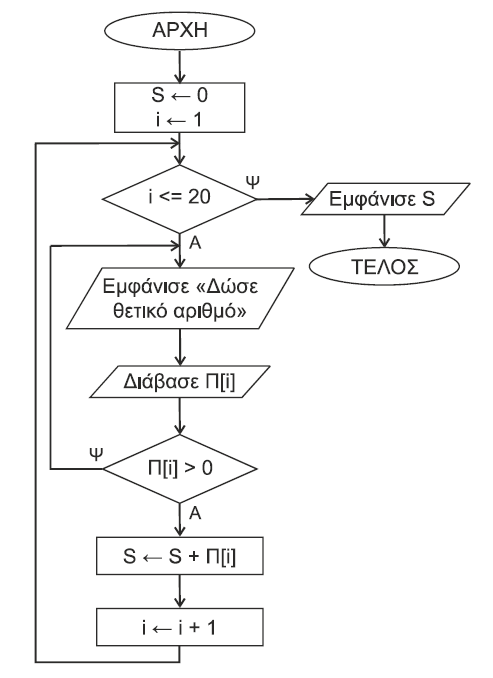
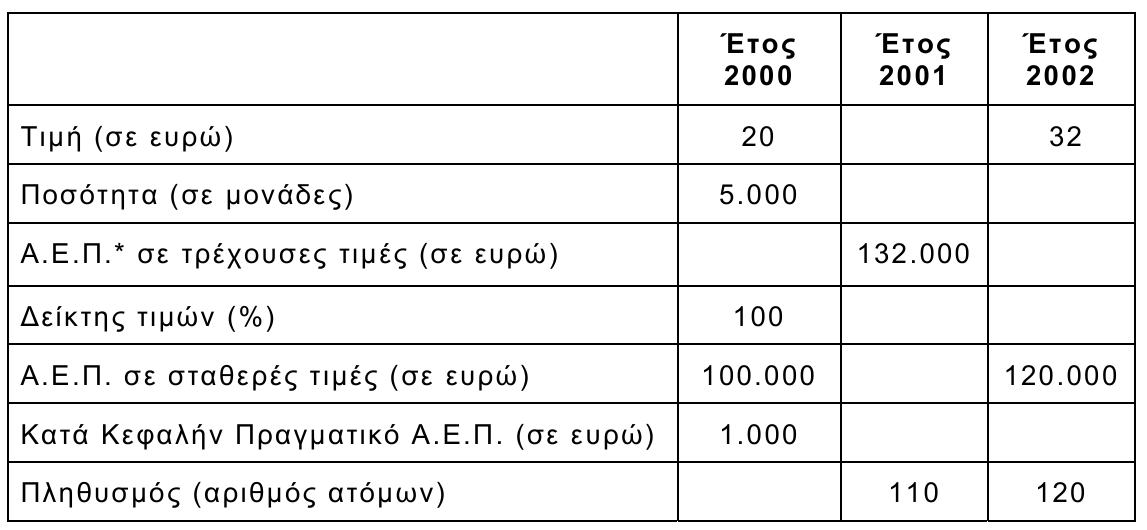
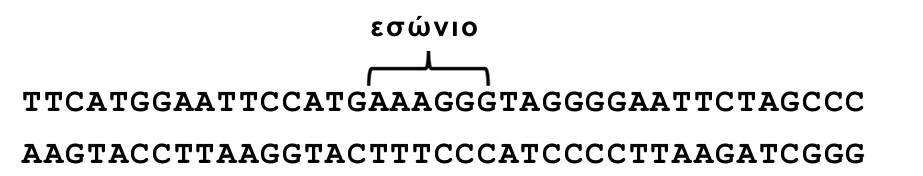

In [32]:
display_samples(df, n=3, prioritize_images=True)

4.1 Distribution by Subject and School Type

,Subject,Count
0,ancient_greek,192
1,latin,177
2,chemistry,175
3,physics,147
4,biology,140
5,mathematics,126
6,economics,115
7,computer_science,90
8,history,84
9,greek_language,72


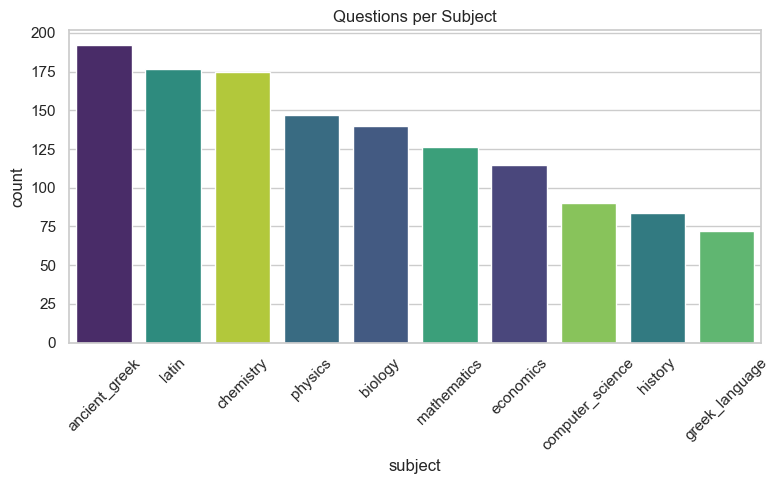

In [6]:
# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

,School Type,Count
0,GEL,1318


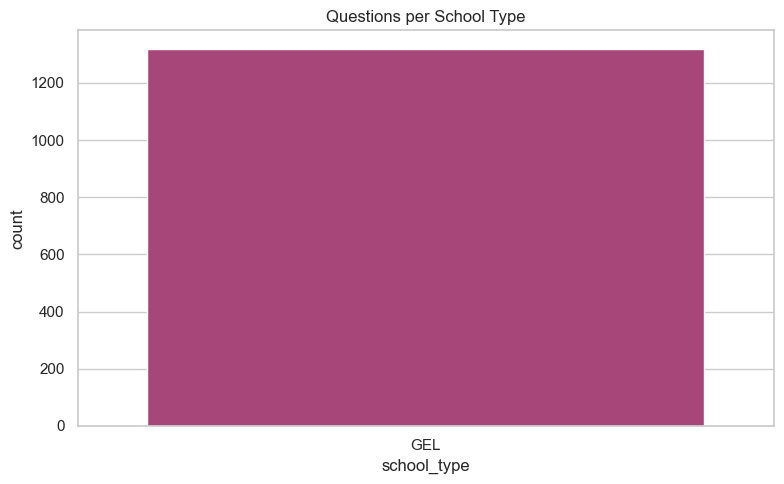

In [7]:
# School Type Distribution
fig_school, df_school = plot_school_type_dist(df)
display(df_school)
display(fig_school)

4.2 Distribution by Format and Reference Type

,Format,Count
0,open_ended,886
1,true_false,228
2,multiple_choice,158
3,fill_in_the_gaps,32
4,matching,14


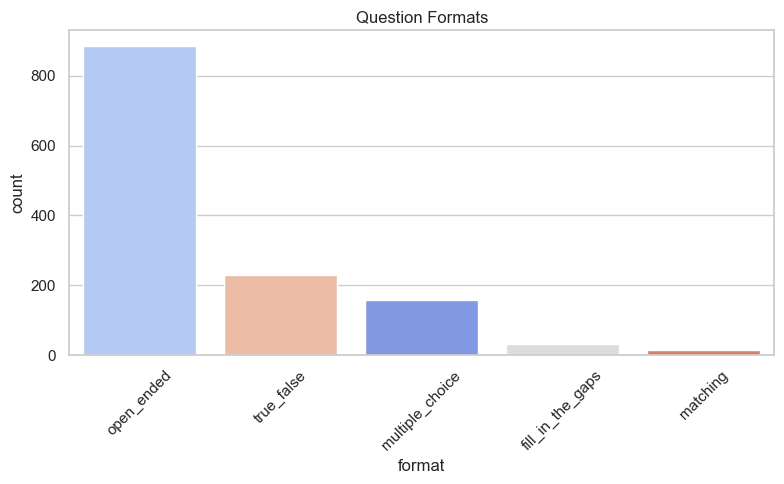

In [8]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

,Reference,Count
0,none,897
1,passage,214
2,multimodal,206
3,table,1


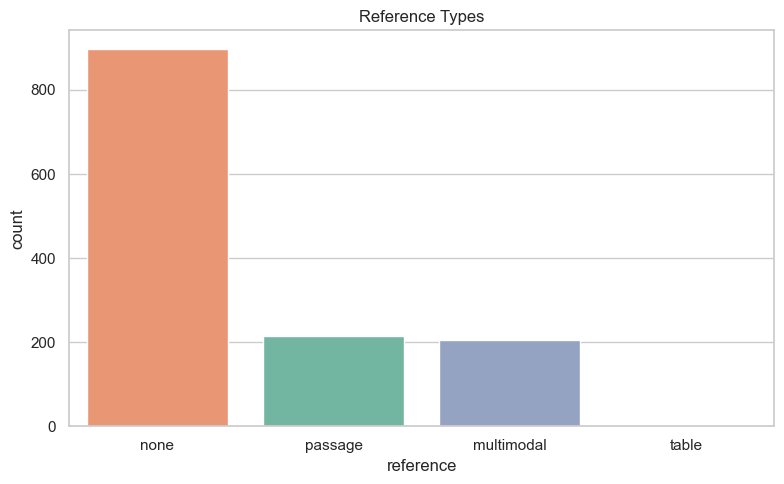

In [9]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

4.3 Temporal Trends

subject,ancient_greek,biology,chemistry,computer_science,economics,greek_language,history,latin,mathematics,physics
year,,,,,,,,,,
2020,33.0,22.0,34.0,16.0,17.0,16.0,14.0,40.0,21.0,24.0
2021,28.0,18.0,25.0,15.0,21.0,11.0,15.0,0.0,22.0,24.0
2022,22.0,22.0,23.0,15.0,20.0,11.0,14.0,33.0,21.0,24.0
2023,35.0,29.0,31.0,14.0,20.0,11.0,14.0,30.0,20.0,26.0
2024,42.0,27.0,33.0,17.0,19.0,11.0,13.0,33.0,22.0,26.0
2025,32.0,22.0,29.0,13.0,18.0,12.0,14.0,41.0,20.0,23.0


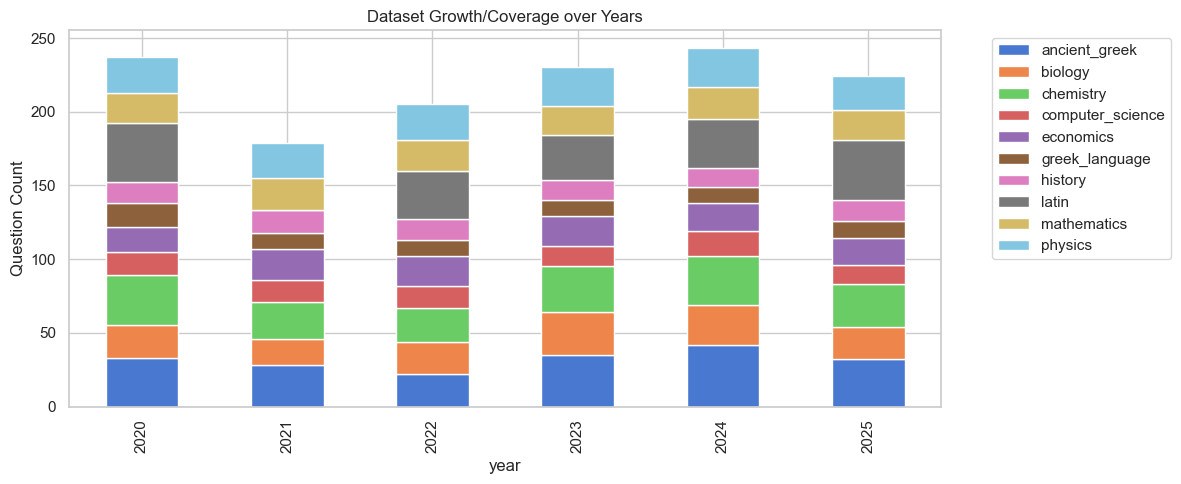

In [10]:
# Temporal Trends (Distribution over years per subject)
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

4.4 Point Values & Format Analysis

Percentage of questions with point values assigned:
100.00%


,count,mean,std,min,25%,50%,75%,max
points,1318.0,4.526176,4.170834,1.0,2.0,3.0,6.0,30.0


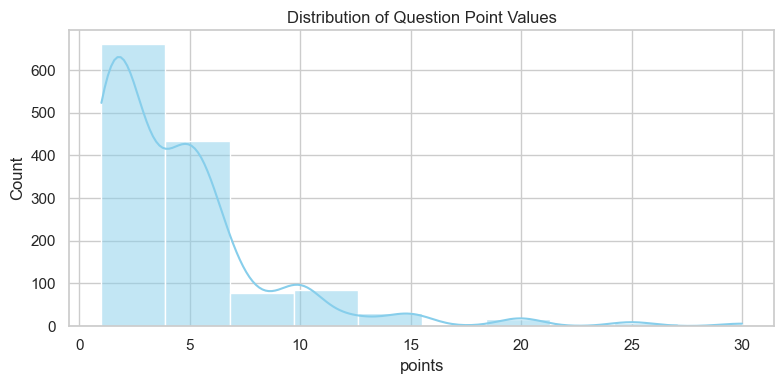

In [11]:
# Points Distribution
fig_points, df_points = plot_points_distribution(df)
display(df_points)
if fig_points is not None:
    display(fig_points)

,count,mean,std,min,25%,50%,75%,max
school_type,,,,,,,,
GEL,1318.0,4.526176,4.170834,1.0,2.0,3.0,6.0,30.0


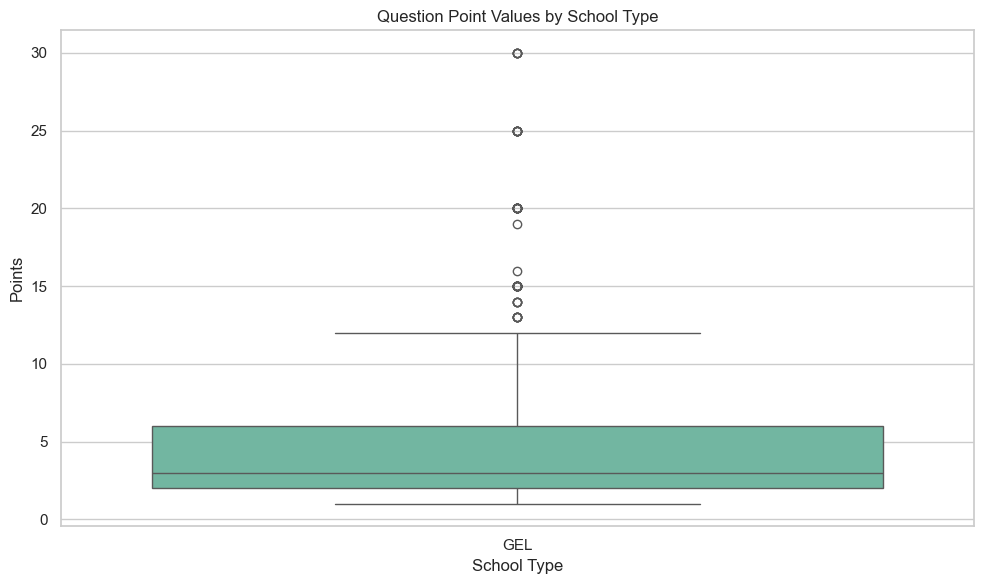

In [12]:
# Points by School Type 
fig_pts_school, df_pts_school = plot_points_by_school_type(df)
display(df_pts_school)
if fig_pts_school is not None:
    display(fig_pts_school)

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
ancient_greek,192.0,3.145833,3.645205,1.0,1.00,2.0,2.00,20.0
biology,140.0,4.400000,1.872943,1.0,3.00,5.0,5.00,10.0
chemistry,175.0,3.531429,1.932150,1.0,2.00,3.0,5.00,10.0
computer_science,90.0,6.655556,6.790875,2.0,2.00,4.5,7.75,25.0
economics,115.0,5.217391,3.316050,2.0,3.00,4.0,6.00,25.0
greek_language,72.0,8.541667,8.332758,1.0,2.00,3.5,15.00,30.0
history,84.0,6.988095,5.200774,2.0,2.00,5.0,12.00,25.0
latin,177.0,2.974576,3.616672,1.0,1.00,1.5,2.00,20.0
mathematics,126.0,4.761905,2.110653,1.0,2.25,5.0,6.00,10.0


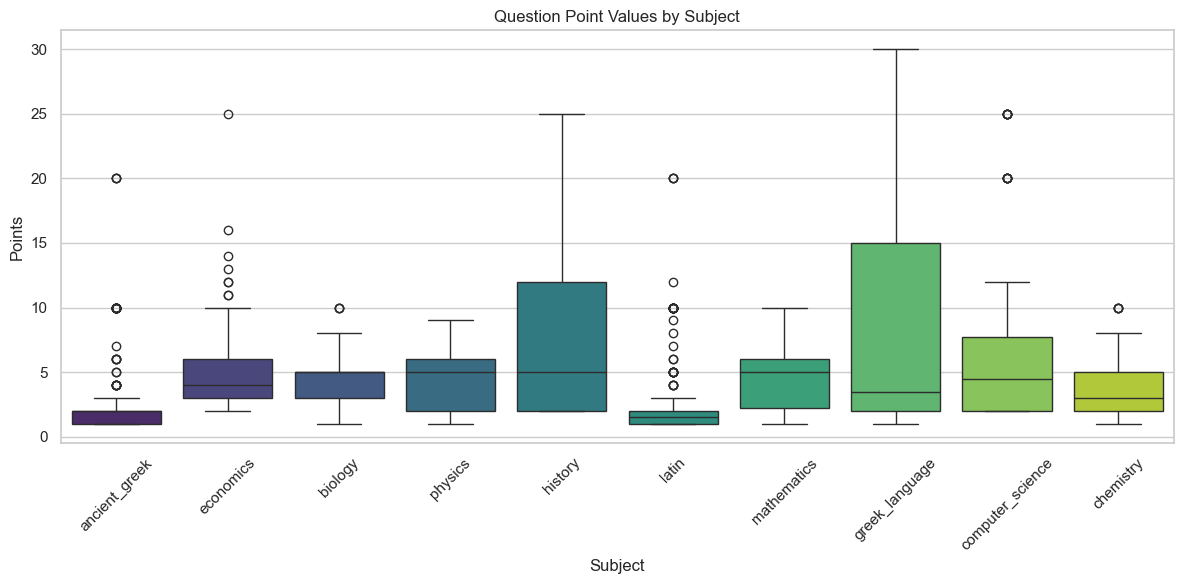

In [13]:
# Points by Subject
fig_pts_subj, df_pts_subj = plot_points_by_subject(df)
display(df_pts_subj)
if fig_pts_subj is not None:
    display(fig_pts_subj)

format,fill_in_the_gaps,matching,multiple_choice,open_ended,true_false
subject,,,,,
ancient_greek,10,6,18,131,27
biology,0,4,37,99,0
chemistry,0,0,32,123,20
computer_science,7,1,0,52,30
economics,5,0,12,68,30
greek_language,0,0,10,42,20
history,0,0,0,54,30
latin,10,3,5,149,10
mathematics,0,0,0,95,31


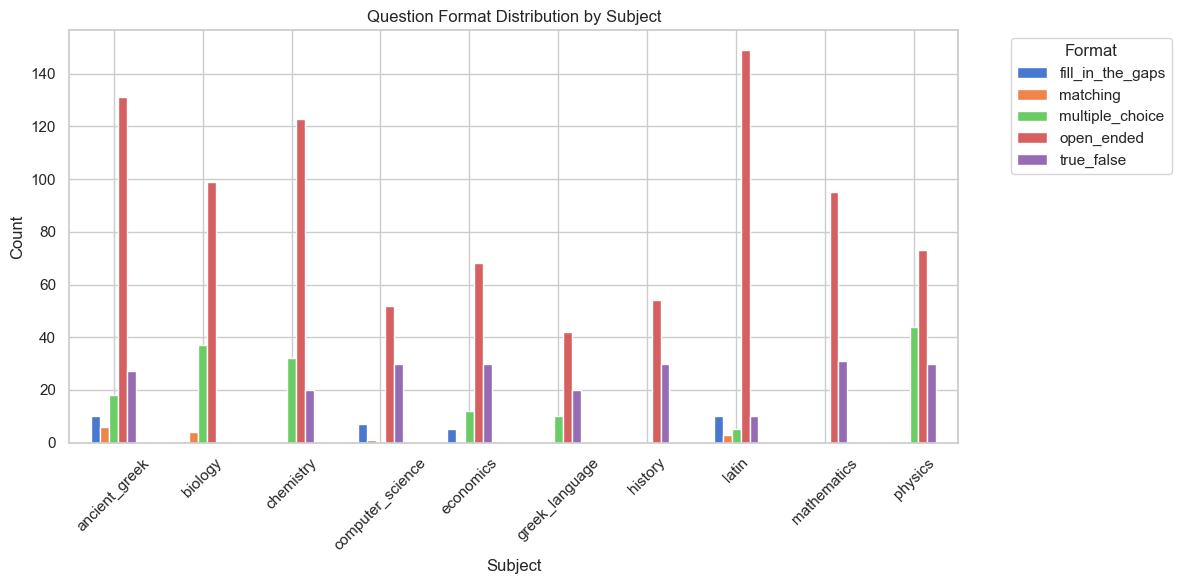

In [14]:
# Format by Subject
fig_fmt, df_fmt = plot_format_by_subject(df)
display(df_fmt)
display(fig_fmt)

4.5 Unique verification

In [15]:
# 1. Μετατρέπουμε προσωρινά τις λίστες (choices) σε tuples για να μπορούν να συγκριθούν
if 'choices' in df.columns:
    choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
else:
    choices_hashable = None

# 2. Έλεγχος μοναδικότητας του 'id'
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")

# 3. Έλεγχος για ερωτήσεις με ολόιδιο περιεχόμενο (Question + Input)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns: subset_to_check.append('input')

if subset_to_check:
    content_duplicates = df.duplicated(subset=subset_to_check).sum()
    print(f"Rows with identical content (Question/Input): {content_duplicates}")
    
    # Αν βρει διπλότυπα, τα τυπώνει για να τα δεις
    if content_duplicates > 0:
        print("\nDisplaying samples of content duplicates:")
        dup_rows = df[df.duplicated(subset=subset_to_check, keep=False)]
        display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question']])

# 4. Έλεγχος για κενές τιμές (nulls) σε κρίσιμες στήλες
critical_cols = ['id', 'subject', 'school_type', 'question', 'format']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\n⚠️ Null values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

Is 'id' column unique? True
Rows with identical content (Question/Input): 2

Displaying samples of content duplicates:


,id,subject,year,question
917,ancient_greek_gel_2021_B4.α,ancient_greek,2021,Να αντιστοιχίσετε στο τετράδιό σας καθεμιά αρχ...
1096,ancient_greek_gel_2020_B4.α,ancient_greek,2020,Να αντιστοιχίσετε στο τετράδιό σας καθεμιά αρχ...
204,chemistry_gel_2025_B1.α.1,chemistry,2025,Ποια δύο (2) από τα παρακάτω άτομα ή ιόντα είν...
205,chemistry_gel_2025_B1.α.2,chemistry,2025,Ποια δύο (2) από τα παρακάτω άτομα ή ιόντα είν...



✅ No null values in critical columns (id, subject, school_type, question, format).


In [16]:
# 1. Βρίσκει γραμμές που έχουν το κυριολεκτικό '\n' (ως κείμενο)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()

# 2. Βρίσκει γραμμές που είναι λίστες μετατρεπόμενες σε strings π.χ. "['a', 'b']"
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()

# 3. Βρίσκει τις "σωστές" απαντήσεις που έχουν πραγματικές αλλαγές γραμμής
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()

print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
if literal_nl_ids: print(f"IDs: {literal_nl_ids[:10]} ...\n")

print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
if json_list_ids: print(f"IDs: {json_list_ids[:10]} ...\n")

print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
if true_multiline_ids: print(f"IDs: {true_multiline_ids[:10]} ...")

📊 Rows with literal '\n': 43
IDs: ['physics_gel_2025_Γ2', 'physics_gel_2025_Γ3', 'physics_gel_2025_Δ4', 'mathematics_gel_2025_A2', 'mathematics_gel_2025_B2', 'physics_gel_2024_B1.β', 'physics_gel_2024_Γ3', 'mathematics_gel_2024_B1', 'mathematics_gel_2024_B2', 'mathematics_gel_2024_Γ4'] ...

📦 Rows with stringified lists: 13
IDs: ['biology_gel_2025_B1', 'latin_gel_2025_B2', 'computer_science_gel_2024_A2', 'ancient_greek_gel_2023_A1.β', 'biology_gel_2023_B1.α', 'ancient_greek_gel_2022_A1.β', 'ancient_greek_gel_2022_B3', 'ancient_greek_gel_2022_B4.α', 'biology_gel_2022_Β1', 'latin_gel_2022_B2'] ...

✅ Rows already using real newlines: 399
IDs: ['ancient_greek_gel_2025_Α1.β', 'ancient_greek_gel_2025_B2', 'ancient_greek_gel_2025_Γ2', 'ancient_greek_gel_2025_Γ3.α', 'economics_gel_2025_B1', 'economics_gel_2025_Γ1', 'economics_gel_2025_Γ2', 'economics_gel_2025_Δ1', 'economics_gel_2025_Δ2.α', 'biology_gel_2025_Γ1.β'] ...


In [17]:
from IPython.display import Markdown

# Φορτώνουμε το dataset απευθείας από το Hugging Face
dataset = load_dataset(repo_id, split="train", token=token)

# Διάλεξε ένα δικό σου ID για τεστ
target_id = "ancient_greek_gel_2025_Α1.α.1" 

subset = dataset.filter(lambda x: x["id"] == target_id)

if len(subset) > 0:
    sample = subset[0]
    
    md_output = f"### ID: {sample['id']}\n"
    md_output += f"**Question:** {sample['question']}\n\n"
    
    if sample.get('input'):
        md_output += f"**Input:**\n{sample['input']}\n\n"
        
    if sample.get('images'):
        md_output += f"🖼️ **Images Attached:** {len(sample['images'])}\n\n"
        
    if sample.get('choices'):
        md_output += "#### Choices:\n"
        correct_idx = sample.get('answer_index')
        for i, choice in enumerate(sample['choices']):
            marker = "✅" if i == correct_idx else "⬜"
            md_output += f"- [{marker}] **{i}**: {choice}\n"
        md_output += f"\n**Correct Answer Index:** `{correct_idx}`"
    else:
        md_output += f"\n**Answer:**\n{sample['answer_text']}"
        
    display(Markdown(md_output))
else:
    print(f"ID {target_id} not found in Hugging Face dataset.")

Filter: 100%|██████████| 1318/1318 [00:00<00:00, 3541.67 examples/s]


### ID: ancient_greek_gel_2025_Α1.α.1
**Question:** Ποια είναι η κύρια αιτία η οποία εμποδίζει τους δεσμώτες να στρέψουν τα κεφάλια τους;

**Input:**
Πλάτωνος Πολιτεία (514a-515c)

Μετὰ ταῦτα δή, εἶπον, ἀπείκασον τοιούτῳ πάθει τὴν ἡμετέραν φύσιν παιδείας τε πέρι καὶ ἀπαιδευσίας. Ἰδὲ γὰρ ἀνθρώπους οἷον ἐν καταγείῳ οἰκήσει σπηλαιώδει, ἀναπεπταμένην πρὸς τὸ φῶς τὴν εἴσοδον ἐχούσῃ μακρὰν παρὰ πᾶν τὸ σπήλαιον, ἐν ταύτῃ ἐκ παίδων ὄντας ἐν δεσμοῖς καὶ τὰ σκέλη καὶ τοὺς αὐχένας, ὥστε μένειν τε αὐτοὺς εἴς τε τὸ πρόσθεν μόνον ὁρᾶν, κύκλῳ δὲ τὰς κεφαλὰς ὑπὸ τοῦ δεσμοῦ ἀδυνάτους περιάγειν, φῶς δὲ αὐτοῖς πυρὸς ἄνωθεν καὶ πόρρωθεν καόμενον ὄπισθεν αὐτῶν, μεταξὺ δὲ τοῦ πυρὸς καὶ τῶν δεσμωτῶν ἐπάνω ὁδόν, παρ’ ἣν ἰδὲ τειχίον παρῳκοδομημένον, ὥσπερ τοῖς θαυματοποιοῖς πρὸ τῶν ἀνθρώπων πρόκειται τὰ παραφράγματα, ὑπὲρ ὧν τὰ θαύματα δεικνύασιν.
Ὁρῶ, ἔφη.
Ὅρα τοίνυν παρὰ τοῦτο τὸ τειχίον φέροντας ἀνθρώπους σκεύη τε παντοδαπὰ ὑπερέχοντα τοῦ τειχίου καὶ ἀνδριάντας καὶ ἄλλα ζῷα λίθινά τε καὶ ξύλινα καὶ παντοῖα εἰργασμένα, οἷον εἰκὸς τοὺς μὲν φθεγγομένους, τοὺς δὲ σιγῶντας τῶν παραφερόντων.
Ἄτοπον, ἔφη, λέγεις εἰκόνα καὶ δεσμώτας ἀτόπους.
Ὁμοίους ἡμῖν, ἦν δ’ ἐγώ· τοὺς γὰρ τοιούτους πρῶτον μὲν ἑαυτῶν τε καὶ ἀλλήλων οἴει ἄν τι ἑωρακέναι ἄλλο πλὴν τὰς σκιὰς τὰς ὑπὸ τοῦ πυρὸς εἰς τὸ καταντικρὺ αὐτῶν τοῦ σπηλαίου προσπιπτούσας;
Πῶς γάρ, ἔφη, εἰ ἀκινήτους γε τὰς κεφαλὰς ἔχειν ἠναγκασμένοι εἶεν διὰ βίου;
Τί δὲ τῶν παραφερομένων; οὐ ταὐτὸν τοῦτο;
Τί μήν;

#### Choices:
- [✅] **0**: α. Οι αλυσίδες στους αυχένες τους.
- [⬜] **1**: β. Το σκοτάδι της σπηλιάς.
- [⬜] **2**: γ. Ο φόβος της φωτιάς.

**Correct Answer Index:** `0`